<a href="https://colab.research.google.com/github/giannismantzaris-cmd/DAMA61/blob/main/Mantzaris_WA4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from tensorflow.keras.datasets import cifar10
(X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [4]:
import numpy as np

print(X_train_full.shape)
print(X_test.shape)


(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [8]:
# The dataset is already split it train (50000)and test (10000) set. But I need
# the full dataset (60000) to shuffle it and split it in train, validation and
# tsst set.
X = np.concatenate([X_train_full, X_test], axis=0)
y = np.concatenate([y_train_full, y_test], axis=0)
print(X.shape)

(60000, 32, 32, 3)


In [9]:
#normalize the data by diving with 255
X = X / 255.

In [11]:
# Shuffle
np.random.seed(42)
indices = np.random.permutation(len(X))
X = X[indices]
y = y[indices]

In [12]:
# Split 60/20/20
X_train = X[:36000]
y_train = y[:36000]

X_valid = X[36000:48000]
y_valid = y[36000:48000]

X_test = X[48000:]
y_test = y[48000:]

In [13]:
# Print shapes
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_valid:", X_valid.shape)
print("y_valid:", y_valid.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (36000, 32, 32, 3)
y_train: (36000, 1)
X_valid: (12000, 32, 32, 3)
y_valid: (12000, 1)
X_test: (12000, 32, 32, 3)
y_test: (12000, 1)


In [15]:
import tensorflow as tf

tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.InputLayer(input_shape=[32, 32, 3]))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(20, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [16]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │        61,460 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,780 (241.33 KB)

 Trainable params: 61,780 (241.33 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
#training and evaluating the model
history = model.fit(X_train, y_train, epochs=30,batch_size=64,
                    validation_data=(X_valid, y_valid))

Epoch 1/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.1495 - loss: 2.2644 - val_accuracy: 0.2498 - val_loss: 2.0941
Epoch 2/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2508 - loss: 2.0516 - val_accuracy: 0.2957 - val_loss: 1.9481
Epoch 3/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2946 - loss: 1.9372 - val_accuracy: 0.3246 - val_loss: 1.8782
Epoch 4/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3256 - loss: 1.8707 - val_accuracy: 0.3469 - val_loss: 1.8227
Epoch 5/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3440 - loss: 1.8228 - val_accuracy: 0.3629 - val_loss: 1.7859
Epoch 6/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3587 - loss: 1.7897 - val_accuracy: 0.3614 - val_loss: 1.7705
Epoch 7/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3684 - loss: 1.7642 - val_accuracy: 0.3738 - val_loss: 1.7470
Epoch 8/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3754 - loss: 1.7437 - val_accuracy: 0.

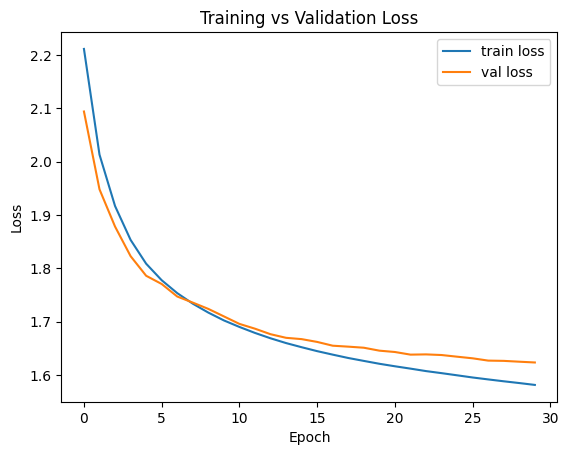

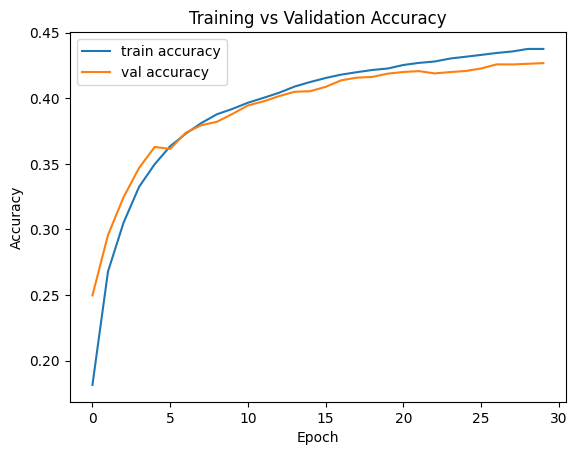

In [19]:
import matplotlib.pyplot as plt

# Loss plot
plt.figure()
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

# Accuracy plot
plt.figure()
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

Both training and validation loss decrease steadily, and training and validation accuracy increase with only a small gap between them. This means there is no overfitting. However, the model accuracy is low, which indicates that the baseline MLP model cannot corrrectly classify CIFAR-10 images and underfits the dataset